In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("data/train.csv",encoding="utf-8")
test_df = pd.read_csv("data/test.csv",encoding="utf-8")

In [3]:
train_df.shape

(891, 12)

In [4]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
test_df.shape

(418, 11)

In [7]:
train_df["train_col"] = 1
test_df["train_col"] = 0

In [8]:
merged_df = pd.concat([train_df,test_df],axis=0)

In [9]:
merged_df.shape

(1309, 13)

In [10]:
merged_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
train_col         0
dtype: int64

In [11]:
get_name = merged_df["Name"].apply(lambda x: x.split(",")[1])
get_title = get_name.apply(lambda x: x.split(".")[0])
merged_df["Title"] = get_title

In [12]:
title_map = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mrs": "Mrs",
    "Mme": "Mrs",
    "Master": "Master",
    "Rev": "Rare",
    "Dr": "Rare",
    "Col": "Rare",
    "Major": "Rare",
    "Don": "Rare",
    "Dona": "Rare",
    "Lady": "Rare",
    "Sir": "Rare",
    "Capt": "Rare",
    "the Countess": "Rare",
    "Jonkheer": "Rare",
}

merged_df["Title"] = merged_df["Title"].str.strip().map(title_map)

In [13]:
merged_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,Mr
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,Rare
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,Mr
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,Mr


In [14]:
cabin_list = merged_df["Cabin"].astype(str).to_list()
cabin_list
cabins = []
for x in cabin_list:
    if str(x) == "nan":
        cabins.append("Unknown")
    else:
        cabins.append(x[0])

merged_df["Cabin_Title"] = cabins

In [15]:
merged_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr,Unknown
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss,Unknown
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr,Unknown


In [16]:
age_df = merged_df.copy()

In [17]:
# age_df = age_df.drop(["Survived","Cabin"],axis=1)

In [18]:
age_df["Fare"] = age_df["Fare"].fillna(age_df["Fare"].median())
age_df["Embarked"] = age_df["Embarked"].fillna(age_df["Embarked"].mode()[0])

In [19]:
age_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
train_col         0
Title             0
Cabin_Title       0
dtype: int64

In [20]:
age_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr,Unknown
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss,Unknown
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr,Unknown


In [21]:
age_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_col', 'Title',
       'Cabin_Title'],
      dtype='str')

In [22]:
from sklearn.preprocessing import OrdinalEncoder

or_cols = ['Title','Embarked','Sex','Ticket']

scalers = {}
for col in or_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    age_df[col] = enc.fit_transform(age_df[[col]])

In [23]:
scale_cols = ["Fare", "SibSp", "Parch"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
age_df[scale_cols] = scaler.fit_transform(age_df[scale_cols])

In [24]:
age_con = age_df["Age"].isna()

age_na = age_df[age_con]
age_not_na = age_df[~age_con]

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iners = []
sil_scores = []

features = ["Pclass","Sex","SibSp","Parch","Embarked","Title"]
data = age_df[features]

r = range(2,40)
for i in r:
    model = KMeans(n_clusters=i)
    model.fit(data)
    iner = model.inertia_
    sil_score = silhouette_score(data, model.predict(data))
    sil_scores.append(sil_score)
    iners.append(iner)
    print(f"n_clusters:{i}, sil_score:{sil_score}, inertia:{iner}")

n_clusters:2, sil_score:0.23487813008221484, inertia:4694.118651044162
n_clusters:3, sil_score:0.3057945104932635, inertia:3469.671118683938
n_clusters:4, sil_score:0.2916867129743368, inertia:3037.189918747071
n_clusters:5, sil_score:0.29905989215053114, inertia:2696.3780202902817
n_clusters:6, sil_score:0.3368169598409701, inertia:2215.4931102216997
n_clusters:7, sil_score:0.3666098548665895, inertia:2000.0387042981597
n_clusters:8, sil_score:0.3599689189505922, inertia:1870.8651112583186
n_clusters:9, sil_score:0.3726416264840865, inertia:1712.0410396584975
n_clusters:10, sil_score:0.388058765655055, inertia:1587.420693765064
n_clusters:11, sil_score:0.4294820459580864, inertia:1596.894654213891
n_clusters:12, sil_score:0.41226766330070047, inertia:1456.2019699033424
n_clusters:13, sil_score:0.4546351096453416, inertia:1236.3330404196695
n_clusters:14, sil_score:0.44182050407069345, inertia:1174.104687978496
n_clusters:15, sil_score:0.46492474278141077, inertia:1117.7494390249815
n_

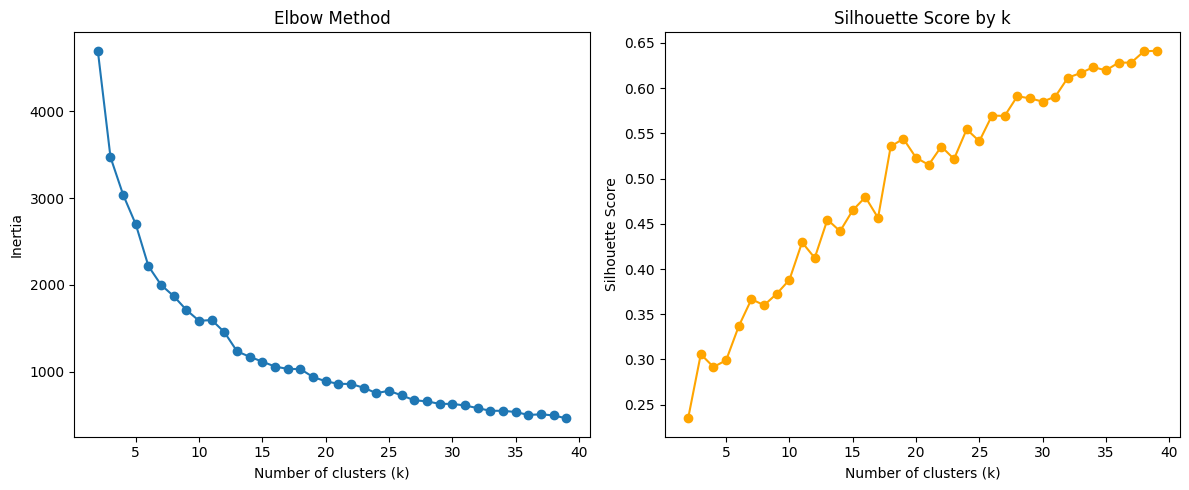

In [26]:
import matplotlib.pyplot as plt

k_range = r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, iners, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

In [27]:
for x in range(1,20):
    k_best = KMeans(n_clusters=x)
    clusters = k_best.fit_predict(age_df[features])
    age_df["cluster"] = clusters

    age_stats = age_df.groupby("cluster")["Age"].agg(["mean", "std", "var", "count"])
    print(age_stats)

              mean        std         var  count
cluster                                         
0        29.881138  14.413493  207.748787   1046
              mean        std         var  count
cluster                                         
0        29.107920  14.055635  197.560868    827
1        32.801005  15.377611  236.470914    219
              mean        std         var  count
cluster                                         
0        31.630812  12.569061  157.981293    702
1        16.215252  15.525333  241.035974    139
2        33.155707  14.481773  209.721746    205
              mean        std         var  count
cluster                                         
0        19.151477  12.072547  145.746400    176
1        34.765625  13.629724  185.769388    192
2        19.930215  16.321538  266.392596     93
3        33.088034  12.519418  156.735815    585
              mean        std         var  count
cluster                                         
0        30.239351  

In [28]:
k_best = KMeans(n_clusters=11)
clusters = k_best.fit_predict(age_df[features])
age_df["cluster"] = clusters

In [29]:
cluster_means = age_df.groupby("cluster")["Age"].transform("mean")
age_df["Age"] = age_df["Age"].fillna(cluster_means)

In [30]:
cluster_means

0      28.526531
1      38.968750
2      24.072222
3      41.197368
4      28.526531
         ...    
413    28.526531
414    38.968750
415    28.526531
416    28.526531
417    24.824651
Name: Age, Length: 1309, dtype: float64

In [31]:
age_df["Age"].isna().sum()

np.int64(0)

In [32]:
age_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
train_col         0
Title             0
Cabin_Title       0
cluster           0
dtype: int64

In [33]:
age_df.shape

(1309, 16)

In [34]:
age_df.Cabin.value_counts()

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F2                 4
                  ..
C39                1
B24                1
D40                1
D38                1
C105               1
Name: count, Length: 186, dtype: int64